# 🗼 Énigmes & Merveilles d'Édouard Lucas

*Un notebook démo pour matheux, dans l'esprit d'Édouard Lucas (1842-1891) — mathématicien français,
inventeur des Tours de Hanoï, théoricien des suites qui portent son nom, auteur du monumental
*Théorie des nombres* (1891) et des quatre volumes de *Récréations mathématiques*, dont une large part
de la mathématique récréative moderne est directement issue.*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses travaux, dans
la continuité de la démo JupyterLab entamée avec Gardner, Pickover, Stewart, Delahaye, du Sautoy, Rucker,
Hofstadter et Smullyan — même recette : calcul, texte, visualisation et interactivité réunis dans un seul
document.

**Sommaire**

1. [Les Tours de Hanoï](#1) — solution récursive
2. [La suite de Lucas](#2) — la cousine de Fibonacci
3. [Les suites de Lucas généralisées U(P,Q), V(P,Q)](#3)
4. [Le théorème de Lucas](#4) — coefficients binomiaux et triangle de Pascal mod p
5. [Le problème des ménages](#5)
6. [Le baguenaudier](#6) — les anneaux chinois
7. [La courbe de poursuite](#7) — le problème des chiens
8. [Le test de primalité de Lucas](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. Les Tours de Hanoï <a id="1"></a>

Lucas invente ce casse-tête en 1883 et le publie sous le pseudonyme "N. Claus de Siam" (anagramme de
"Lucas d'Amiens"), l'habillant d'une légende de moines vietnamiens déplaçant 64 disques d'or sur trois
piquets de diamant. Trois piquets, une pile de disques de tailles décroissantes, une seule règle : ne
jamais poser un disque sur un plus petit. La solution récursive — déplacer n-1 disques, déplacer le
dernier, redéplacer les n-1 — est devenue l'un des tout premiers exemples pédagogiques de récursivité en
informatique, avec un nombre de coups minimal exactement égal à $2^n - 1$.

Tours de Hanoï à 5 disques : 31 coups nécessaires (= 2^5 - 1 = 31)
Dix premiers coups : [('A', 'C'), ('A', 'B'), ('C', 'B'), ('A', 'C'), ('B', 'A'), ('B', 'C'), ('A', 'C'), ('A', 'B'), ('C', 'B'), ('C', 'A')]


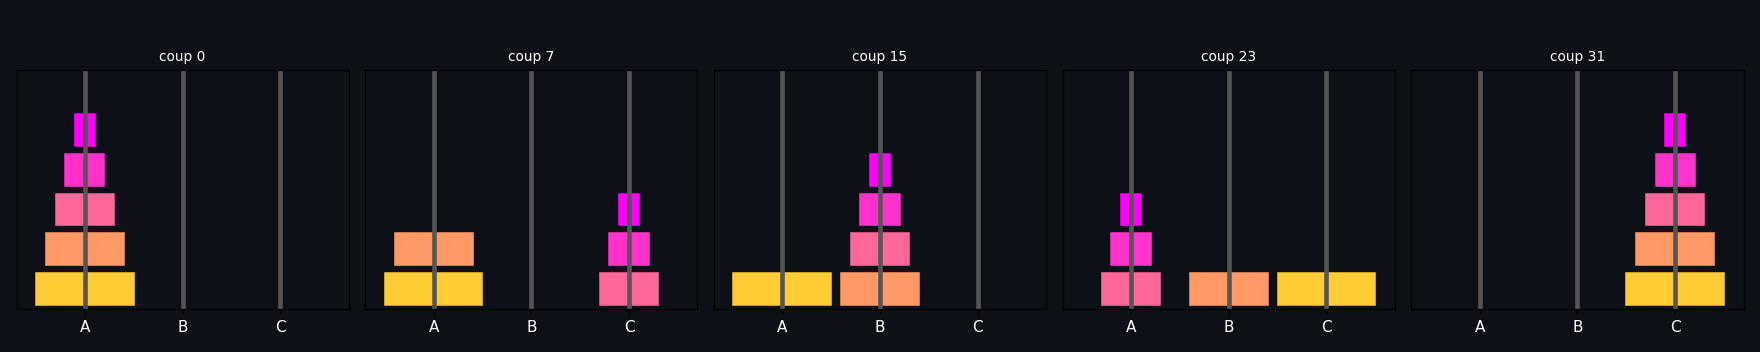

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Édouard Lucas invente les Tours de Hanoï en 1883, publiées sous le pseudonyme
# "N. Claus de Siam" (anagramme de "Lucas d'Amiens"). Trois piquets, une pile de
# disques de tailles décroissantes : les déplacer un par un vers un autre piquet
# sans jamais poser un disque sur un plus petit. La solution récursive est un
# des tout premiers exemples pédagogiques de récursivité en informatique.

def hanoi(n, source, aux, target, moves):
    if n == 0:
        return
    hanoi(n-1, source, target, aux, moves)
    moves.append((source, target))
    hanoi(n-1, aux, source, target, moves)

N = 5
moves = []
hanoi(N, "A", "B", "C", moves)
print(f"Tours de Hanoï à {N} disques : {len(moves)} coups nécessaires (= 2^{N} - 1 = {2**N - 1})")
print("Dix premiers coups :", moves[:10])

# Simulation : on rejoue tous les coups et on capture l'état des piquets à quelques étapes.
step_targets = [0, len(moves)//4, len(moves)//2, 3*len(moves)//4, len(moves)]
state = {"A": list(range(N, 0, -1)), "B": [], "C": []}
states_at = [(0, {k: v[:] for k, v in state.items()})]
for i, (src, tgt) in enumerate(moves, start=1):
    disk = state[src].pop()
    state[tgt].append(disk)
    if i in step_targets:
        states_at.append((i, {k: v[:] for k, v in state.items()}))

fig, axes = plt.subplots(1, len(states_at), figsize=(16, 3.2), facecolor="#0d1117")
colors_disk = plt.cm.spring([x/N for x in range(N)])
for ax, (step, st) in zip(axes, states_at):
    ax.set_facecolor("#0d1117")
    for pi, peg in enumerate(["A", "B", "C"]):
        ax.plot([pi, pi], [0, N+1], color="#555", lw=3)
        for h, disk in enumerate(st[peg]):
            width = disk / N
            ax.add_patch(plt.Rectangle((pi-width/2, h+0.1), width, 0.8, color=colors_disk[disk-1]))
    ax.set_xlim(-0.7, 2.7); ax.set_ylim(0, N+1)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["A","B","C"], color="white")
    ax.set_yticks([])
    ax.set_title(f"coup {step}", color="white", fontsize=9)
fig.suptitle(f"Tours de Hanoï, {N} disques — {len(moves)} coups au total", color="white", fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())


## 2. La suite de Lucas <a id="2"></a>

La suite qui porte directement son nom est la cousine méconnue de Fibonacci : même récurrence
$L(n)=L(n-1)+L(n-2)$, mais des valeurs de départ différentes ($L(0)=2$, $L(1)=1$). Les deux suites sont
liées par des identités élégantes — $L(n) = F(n-1)+F(n+1)$, et surtout $L(n)^2 - 5F(n)^2 = 4(-1)^n$ —
que Lucas exploite systématiquement dans ses travaux sur la primalité, notamment pour tester les nombres
de Mersenne bien avant l'ère informatique.

Suite de Lucas   : [2, 1, 3, 4, 7, 11, 18, 29, 47, 76, 123, 199, 322, 521, 843]
Suite de Fibonacci: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]

Identité L(n) = F(n-1) + F(n+1) vérifiée pour n=1..24 : True
Identité L(n)² − 5F(n)² = 4(−1)ⁿ vérifiée pour n=0..24 : True


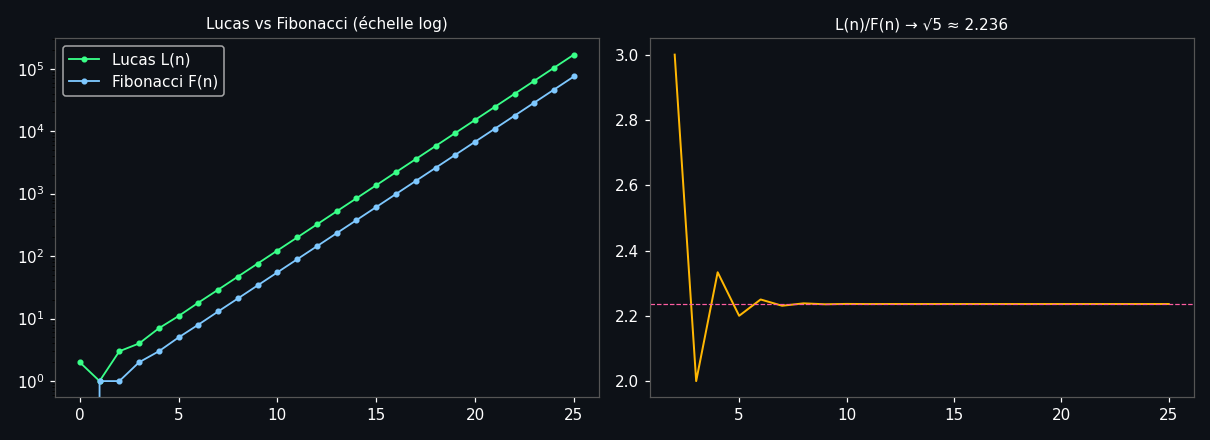

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# La suite qui porte le nom de Lucas est la cousine de Fibonacci : mêmes règles
# de récurrence, mais des valeurs de départ différentes.
# L(0) = 2, L(1) = 1, L(n) = L(n-1) + L(n-2).
def lucas_seq(n_max):
    L = [2, 1]
    for _ in range(2, n_max+1):
        L.append(L[-1] + L[-2])
    return L

def fib_seq(n_max):
    F = [0, 1]
    for _ in range(2, n_max+1):
        F.append(F[-1] + F[-2])
    return F

N = 25
L = lucas_seq(N)
F = fib_seq(N)
print("Suite de Lucas   :", L[:15])
print("Suite de Fibonacci:", F[:15])

# Identité reliant les deux suites : L(n) = F(n-1) + F(n+1)
ok = all(L[n] == F[n-1] + F[n+1] for n in range(1, N))
print(f"\nIdentité L(n) = F(n-1) + F(n+1) vérifiée pour n=1..{N-1} : {ok}")

# Identité de Lucas : L(n)^2 - 5 F(n)^2 = 4 (-1)^n
ok2 = all(L[n]**2 - 5*F[n]**2 == 4*(-1)**n for n in range(N))
print(f"Identité L(n)² − 5F(n)² = 4(−1)ⁿ vérifiée pour n=0..{N-1} : {ok2}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor="#0d1117")
for ax in axes: ax.set_facecolor("#0d1117")
axes[0].plot(range(N+1), L, color="#39ff88", marker="o", markersize=3, lw=1.2, label="Lucas L(n)")
axes[0].plot(range(N+1), F, color="#7ec8ff", marker="o", markersize=3, lw=1.2, label="Fibonacci F(n)")
axes[0].set_yscale("log")
axes[0].legend(facecolor="#0d1117", labelcolor="white")
axes[0].set_title("Lucas vs Fibonacci (échelle log)", color="white", fontsize=10)

ratios = [L[n]/F[n] for n in range(2, N+1)]
axes[1].plot(range(2, N+1), ratios, color="#ffb703", lw=1.3)
axes[1].axhline(5**0.5, color="#ff5da2", lw=0.8, ls="--")
axes[1].set_title("L(n)/F(n) → √5 ≈ 2.236", color="white", fontsize=10)

for ax in axes:
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_color("#555")
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Les suites de Lucas généralisées U(P,Q), V(P,Q) <a id="3"></a>

Le grand œuvre théorique de Lucas (*Théorie des fonctions numériques simplement périodiques*, 1878) va
bien au-delà de Fibonacci : il définit une famille entière de suites $U_n(P,Q)$ et $V_n(P,Q)$ dépendant de
deux paramètres entiers. Selon le choix de $P$ et $Q$, on retrouve Fibonacci et Lucas eux-mêmes, mais
aussi les nombres de Pell, de Jacobsthal, ou même les nombres de Mersenne $2^n-1$ — un unique cadre
algébrique unifiant une bonne partie de la théorie des nombres récréative de l'époque.

Fibonacci / Lucas   (P=1, Q=-1) : U_n = [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
Pell / Pell-Lucas    (P=2, Q=-1) : U_n = [0, 1, 2, 5, 12, 29, 70, 169, 408, 985, 2378]
Jacobsthal           (P=1, Q=-2) : U_n = [0, 1, 1, 3, 5, 11, 21, 43, 85, 171, 341]
Mersenne (2^n - 1)   (P=3, Q=2) : U_n = [0, 1, 3, 7, 15, 31, 63, 127, 255, 511, 1023]

Vérification : U_n(3,2) redonne bien 2^n - 1 : [0, 1, 3, 7, 15, 31, 63, 127, 255] = [0, 1, 3, 7, 15, 31, 63, 127, 255]


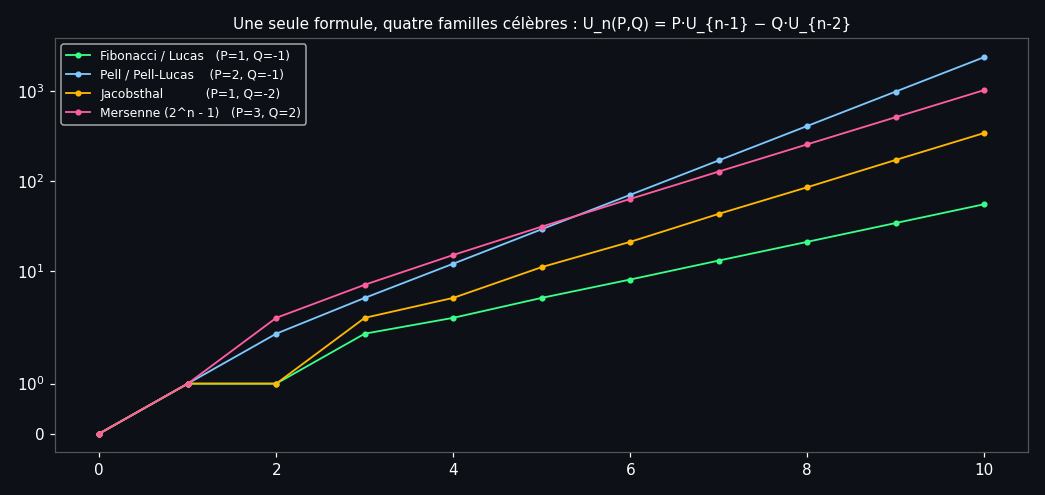

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Le grand œuvre théorique de Lucas ("Théorie des fonctions numériques simplement
# périodiques", 1878) : une famille de suites U_n(P,Q) et V_n(P,Q) qui, selon le
# choix de deux paramètres entiers P et Q, redonnent Fibonacci, Lucas, les
# nombres de Pell, de Jacobsthal, ou encore les nombres de Mersenne — un cadre
# unificateur pour une bonne partie de la théorie des nombres récréative.

def lucas_UV(P, Q, n_max):
    U = [0, 1]
    V = [2, P]
    for n in range(2, n_max+1):
        U.append(P*U[-1] - Q*U[-2])
        V.append(P*V[-1] - Q*V[-2])
    return U, V

familles = {
    "Fibonacci / Lucas   (P=1, Q=-1)": (1, -1),
    "Pell / Pell-Lucas    (P=2, Q=-1)": (2, -1),
    "Jacobsthal           (P=1, Q=-2)": (1, -2),
    "Mersenne (2^n - 1)   (P=3, Q=2)":  (3, 2),
}

N = 10
fig, ax = plt.subplots(figsize=(9.5, 4.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors = ["#39ff88", "#7ec8ff", "#ffb703", "#ff5da2"]
for (label, (P, Q)), color in zip(familles.items(), colors):
    U, V = lucas_UV(P, Q, N)
    print(f"{label} : U_n = {U}")
    ax.plot(range(N+1), U, color=color, marker="o", markersize=3, lw=1.2, label=label)

ax.set_yscale("symlog")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white", fontsize=8)
ax.set_title("Une seule formule, quatre familles célèbres : U_n(P,Q) = P·U_{n-1} − Q·U_{n-2}", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out3.png", dpi=110, facecolor=fig.get_facecolor())

U_mersenne, _ = lucas_UV(3, 2, 8)
print("\nVérification : U_n(3,2) redonne bien 2^n - 1 :", U_mersenne, "=", [2**n - 1 for n in range(9)])


## 4. Le théorème de Lucas <a id="4"></a>

Publié en 1878 : pour calculer un coefficient binomial $C(m,n)$ modulo un nombre premier $p$, il suffit
d'écrire $m$ et $n$ en base $p$, chiffre par chiffre, puis de multiplier les $C(m_i, n_i)$ obtenus — plus
besoin de calculer le coefficient complet, souvent astronomique. Appliqué à $p=2$, ce théorème explique
directement pourquoi le triangle de Pascal réduit modulo 2 dessine le motif fractal du triangle de
Sierpinski : un bit est impair exactement quand chaque chiffre binaire de $n$ est inférieur ou égal au
chiffre correspondant de $m$.

Vérification du théorème de Lucas modulo p = 5 :
  C(19,12) mod 5 : calcul direct = 3, via Lucas = 3  OK
  C(73,72) mod 5 : calcul direct = 3, via Lucas = 3  OK
  C(199,53) mod 5 : calcul direct = 4, via Lucas = 4  OK
  C(122,75) mod 5 : calcul direct = 4, via Lucas = 4  OK


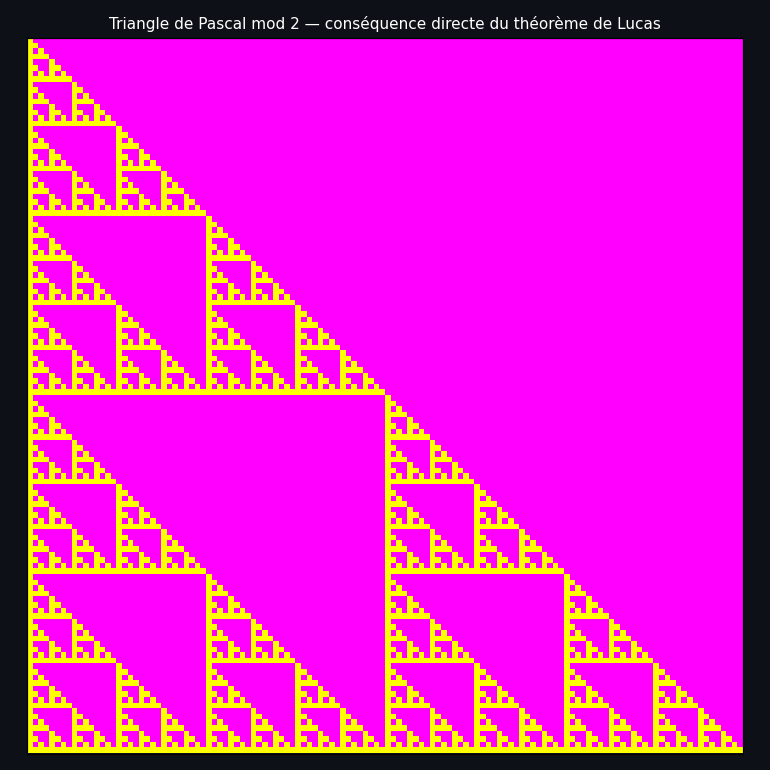

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from math import comb

# Le théorème de Lucas (1878) : pour calculer C(m, n) modulo un nombre premier p,
# il suffit d'écrire m et n en base p, chiffre par chiffre, et de multiplier les
# C(m_i, n_i) obtenus -- inutile de calculer le coefficient binomial complet,
# souvent gigantesque.

def digits_base_p(x, p):
    if x == 0: return [0]
    d = []
    while x > 0:
        d.append(x % p)
        x //= p
    return d[::-1]

def lucas_binom_mod_p(m, n, p):
    dm = digits_base_p(m, p)
    dn = digits_base_p(n, p)
    dn = [0]*(len(dm)-len(dn)) + dn
    result = 1
    for a, b in zip(dm, dn):
        if b > a:
            return 0
        result = (result * comb(a, b)) % p
    return result

p = 5
tests = [(19, 12), (73, 72), (199, 53), (122, 75)]
print(f"Vérification du théorème de Lucas modulo p = {p} :")
for m, n in tests:
    direct = comb(m, n) % p
    via_lucas = lucas_binom_mod_p(m, n, p)
    print(f"  C({m},{n}) mod {p} : calcul direct = {direct}, via Lucas = {via_lucas}  {'OK' if direct==via_lucas else 'ERREUR'}")

# Triangle de Pascal modulo 2 : le théorème de Lucas explique directement
# pourquoi le motif obtenu est le triangle de Sierpinski -- C(m,n) est impair
# exactement quand chaque chiffre binaire de n est <= au chiffre correspondant de m.
SIZE = 128
triangle = np.zeros((SIZE, SIZE), dtype=int)
row = [1]
for i in range(SIZE):
    for j, v in enumerate(row):
        triangle[i, j] = v % 2
    new_row = [1] + [row[k]+row[k+1] for k in range(len(row)-1)] + [1]
    row = new_row

fig, ax = plt.subplots(figsize=(7, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.imshow(triangle, cmap="spring", interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Triangle de Pascal mod 2 — conséquence directe du théorème de Lucas", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())


## 5. Le problème des ménages <a id="5"></a>

Posé par Lucas en 1891 : de combien de façons peut-on asseoir $n$ couples autour d'une table ronde,
hommes et femmes alternés, sans qu'aucune personne ne se retrouve à côté de son propre conjoint ? La
question restera ouverte jusqu'à ce que Jacques Touchard en donne la formule close en 1934 — une élégante
somme alternée qui se vérifie exactement contre un dénombrement par force brute pour les petits cas.

Vérification (force brute vs formule de Touchard) pour petits n :
  n=3 couples : force brute = 1, formule = 1  OK
  n=4 couples : force brute = 2, formule = 2  OK
  n=5 couples : force brute = 13, formule = 13  OK
  n=6 couples : force brute = 80, formule = 80  OK


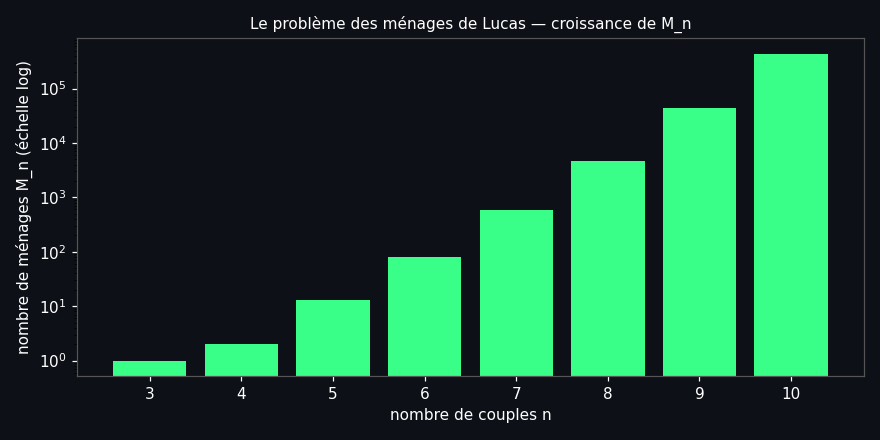

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import permutations
from math import comb, factorial

# Lucas pose en 1891 le "problème des ménages" : de combien de façons peut-on
# asseoir n couples autour d'une table ronde, hommes et femmes alternés, sans
# qu'aucune personne ne se retrouve à côté de son propre conjoint ? La formule
# close (due à Touchard, 1934, en réponse directe à la question de Lucas) :
#   M_n = sum_{k=0}^{n} (-1)^k * (2n / (2n-k)) * C(2n-k, k) * (n-k)!

def menage_number(n):
    total = 0
    for k in range(0, n+1):
        if 2*n - k == 0:
            continue
        term = (-1)**k * (2*n / (2*n - k)) * comb(2*n - k, k) * factorial(n - k)
        total += term
    return round(total)

def menage_brute_force(n):
    """Vérification par force brute pour petit n : les femmes sont fixées,
    on compte les permutations des hommes évitant les positions interdites."""
    count = 0
    for perm in permutations(range(n)):
        # homme perm[i] assis entre femme i et femme (i+1) mod n
        ok = True
        for i in range(n):
            if perm[i] == i or perm[i] == (i - 1) % n:
                ok = False
                break
        if ok:
            count += 1
    return count

print("Vérification (force brute vs formule de Touchard) pour petits n :")
for n in range(3, 7):
    bf = menage_brute_force(n)
    formule = menage_number(n)
    print(f"  n={n} couples : force brute = {bf}, formule = {formule}  {'OK' if bf==formule else 'ERREUR'}")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ns = list(range(3, 11))
values = [menage_number(n) for n in ns]
ax.bar([str(n) for n in ns], values, color="#39ff88")
ax.set_yscale("log")
ax.set_xlabel("nombre de couples n", color="white")
ax.set_ylabel("nombre de ménages M_n (échelle log)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Le problème des ménages de Lucas — croissance de M_n", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())


## 6. Le baguenaudier <a id="6"></a>

Les *Récréations mathématiques* de Lucas consacrent des pages entières au baguenaudier (les "anneaux
chinois"), un casse-tête bien antérieur à lui mais qu'il est le premier à analyser complètement en
mathématicien. Il démontre que le nombre minimal de coups pour le résoudre suit une récurrence très
proche de celle des Tours de Hanoï — et que chaque état successif du puzzle correspond exactement à un
mot d'un code de Gray, reliant ainsi un jouet séculaire à la combinatoire binaire moderne.

Nombre minimal de coups pour résoudre le baguenaudier à n anneaux :
  n= 1 anneaux ->     1 coups
  n= 2 anneaux ->     2 coups
  n= 3 anneaux ->     5 coups
  n= 4 anneaux ->    10 coups
  n= 5 anneaux ->    21 coups
  n= 6 anneaux ->    42 coups
  n= 7 anneaux ->    85 coups
  n= 8 anneaux ->   170 coups
  n= 9 anneaux ->   341 coups
  n=10 anneaux ->   682 coups
  n=11 anneaux ->  1365 coups
  n=12 anneaux ->  2730 coups

Formule close vérifiée pour n=1..12 : True


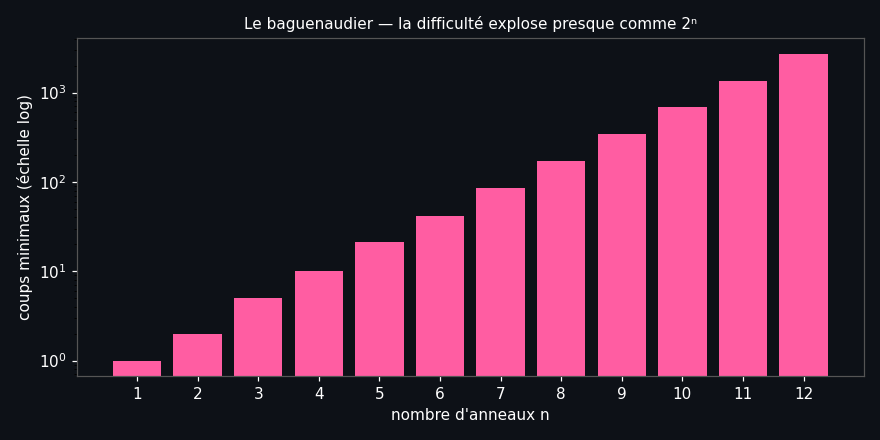

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Lucas a consacré des pages entières de ses "Récréations mathématiques" au
# baguenaudier (les "anneaux chinois"), un casse-tête bien plus ancien que lui
# mais qu'il est le premier à analyser complètement en mathématicien : il montre
# que le nombre minimal de coups pour le résoudre suit une récurrence proche de
# celle des Tours de Hanoï, et que chaque état du puzzle correspond exactement à
# un mot de code de Gray.

def moves_baguenaudier(n_max):
    a = [0, 1, 2]  # a[0] inutilisé, a[1]=1, a[2]=2
    for n in range(3, n_max+1):
        a.append(a[n-1] + 2*a[n-2] + 1)
    return a[1:]

moves = moves_baguenaudier(12)
print("Nombre minimal de coups pour résoudre le baguenaudier à n anneaux :")
for n, m in enumerate(moves, start=1):
    print(f"  n={n:2d} anneaux -> {m:5d} coups")

# Formule close équivalente (nombres de Jacobsthal) :  a(n) = floor((2^(n+1) - (-1)^n) / 3) ... - 1
# On vérifie ici la formule habituellement citée : a(n) = (2^(n+1) - 2)/3 si n pair, (2^(n+1)-1)/3 si n impair
def formule_close(n):
    if n % 2 == 0:
        return (2**(n+1) - 2) // 3
    return (2**(n+1) - 1) // 3

ok = all(formule_close(n) == m for n, m in enumerate(moves, start=1))
print(f"\nFormule close vérifiée pour n=1..{len(moves)} : {ok}")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ns = list(range(1, len(moves)+1))
ax.bar([str(n) for n in ns], moves, color="#ff5da2")
ax.set_yscale("log")
ax.set_xlabel("nombre d'anneaux n", color="white")
ax.set_ylabel("coups minimaux (échelle log)", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Le baguenaudier — la difficulté explose presque comme 2ⁿ", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())


## 7. La courbe de poursuite <a id="7"></a>

Une des récréations favorites de Lucas : $n$ points placés aux sommets d'un polygone régulier (des
"chiens", des souris ou des scarabées selon les versions), chacun poursuivant en permanence son voisin
immédiat à vitesse constante. Les trajectoires qui en résultent sont des spirales logarithmiques,
identiques les unes aux autres à une rotation près par symétrie, qui convergent toutes inexorablement
vers le centre du polygone de départ.

Chaque poursuivant vise toujours son voisin immédiat : les n trajectoires,
par symétrie, sont des spirales logarithmiques identiques tournées les unes des autres,
qui convergent toutes vers le centre du polygone de départ.


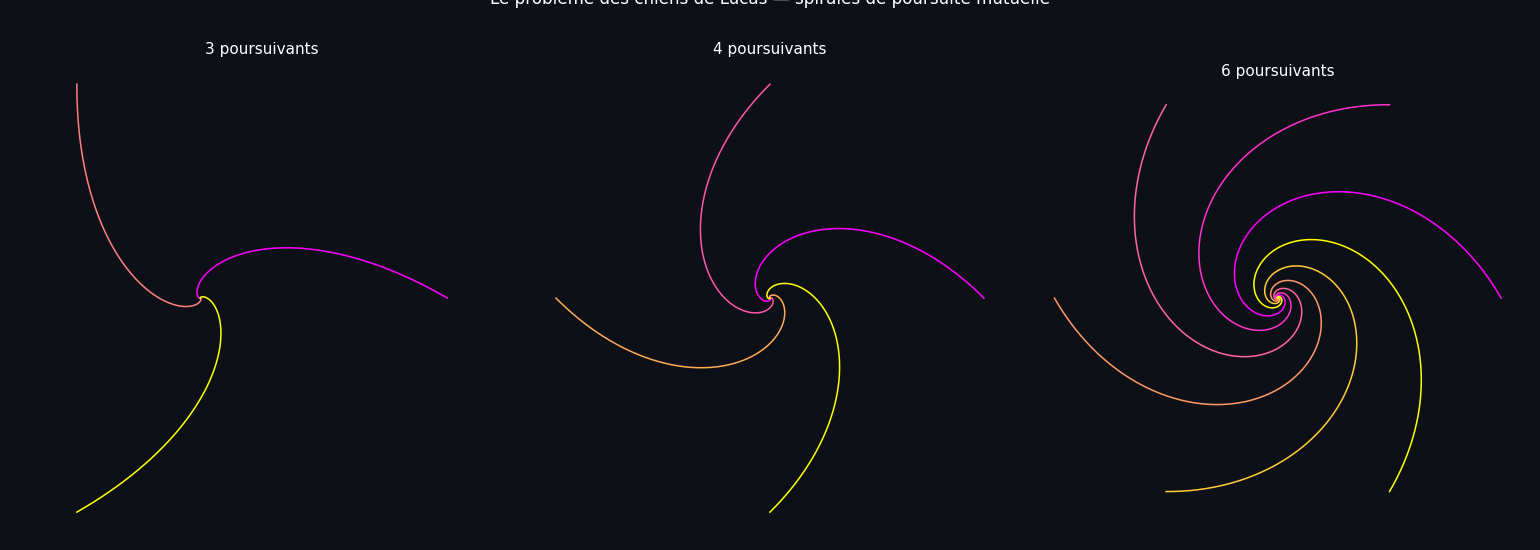

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# Le "problème des chiens" (ou des souris, ou des scarabées, selon les
# traductions) figure parmi les récréations préférées de Lucas : n points
# placés aux sommets d'un polygone régulier, chacun poursuivant son voisin
# à vitesse constante et se dirigeant toujours droit sur lui. Les trajectoires
# dessinent des spirales logarithmiques qui convergent toutes vers le centre,
# en tournant d'autant plus serré que n est grand.

def simulate_pursuit(n, steps=4000, speed=0.01):
    angles = [2*np.pi*k/n for k in range(n)]
    pos = np.array([[np.cos(a), np.sin(a)] for a in angles])
    trails = [[] for _ in range(n)]
    for _ in range(steps):
        new_pos = pos.copy()
        for i in range(n):
            target = pos[(i+1) % n]
            direction = target - pos[i]
            dist = np.linalg.norm(direction)
            if dist > 1e-4:
                new_pos[i] = pos[i] + speed * direction / dist * min(dist, 1.0)
            trails[i].append(pos[i].copy())
        pos = new_pos
    return trails

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="#0d1117")
for ax, n in zip(axes, [3, 4, 6]):
    ax.set_facecolor("#0d1117")
    trails = simulate_pursuit(n, steps=3000, speed=0.012)
    colors = plt.cm.spring(np.linspace(0, 1, n))
    for i in range(n):
        pts = np.array(trails[i])
        ax.plot(pts[:,0], pts[:,1], color=colors[i], lw=1)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"{n} poursuivants", color="white", fontsize=10)

fig.suptitle("Le problème des chiens de Lucas — spirales de poursuite mutuelle", color="white", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("out7.png", dpi=110, facecolor=fig.get_facecolor())
print("Chaque poursuivant vise toujours son voisin immédiat : les n trajectoires,")
print("par symétrie, sont des spirales logarithmiques identiques tournées les unes des autres,")
print("qui convergent toutes vers le centre du polygone de départ.")


## 8. Le test de primalité de Lucas <a id="8"></a>

À ne pas confondre avec le test de Lucas-Lehmer (spécifique aux nombres de Mersenne) : le test de
primalité de Lucas, plus général, publié en 1876, s'appuie sur la réciproque du petit théorème de Fermat.
$n$ est premier s'il existe un témoin $a$ tel que $a^{n-1}\equiv 1 \pmod n$, mais
$a^{(n-1)/q} \not\equiv 1 \pmod n$ pour *chaque* facteur premier $q$ de $n-1$ — une condition bien plus
exigeante que le simple test de Fermat, au point de démasquer même les nombres de Carmichael, ces
"faux positifs" retors qui trompent Fermat pour presque tous les témoins.

n=   97 : PREMIER, témoin de Lucas trouvé a=5 (facteurs de n-1 : [2, 3])
n=  991 : PREMIER, témoin de Lucas trouvé a=6 (facteurs de n-1 : [2, 3, 5, 11])
n= 1000 : le test ne trouve aucun témoin -> composé (ou témoin hors de la plage testée)
n=  561 : le test ne trouve aucun témoin -> composé (ou témoin hors de la plage testée)

561 = 3 × 11 × 17 est le plus petit nombre de Carmichael : il trompe le simple test de Fermat
(a^560 ≡ 1 mod 561 pour presque tout a), mais le test de Lucas, plus exigeant, le démasque.


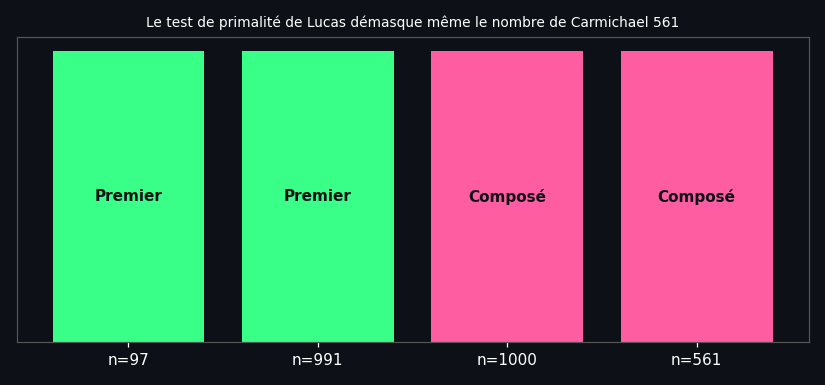

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# À ne pas confondre avec le test de Lucas-Lehmer (spécifique aux nombres de
# Mersenne) : le test de primalité de LUCAS, plus général (1876), s'appuie sur
# la réciproque du petit théorème de Fermat. n est premier si l'on trouve un
# témoin a tel que a^(n-1) = 1 (mod n), MAIS a^((n-1)/q) != 1 (mod n) pour
# CHAQUE facteur premier q de n-1 -- ce qui garantit que a a pour ordre exact
# n-1, la signature d'un groupe multiplicatif de taille n-1 tout entier.

def facteurs_premiers(n):
    facteurs = set()
    d = 2
    while d*d <= n:
        while n % d == 0:
            facteurs.add(d)
            n //= d
        d += 1
    if n > 1:
        facteurs.add(n)
    return facteurs

def lucas_primality_test(n, temoin_max=50):
    if n < 3:
        return None
    q_facteurs = facteurs_premiers(n - 1)
    for a in range(2, temoin_max):
        if pow(a, n-1, n) != 1:
            continue
        if all(pow(a, (n-1)//q, n) != 1 for q in q_facteurs):
            return True, a
    return False, None

for n in [97, 991, 1000, 561]:  # 561 est un nombre de Carmichael (pseudo-premier retors)
    resultat = lucas_primality_test(n)
    if resultat[0] is True:
        print(f"n={n:5d} : PREMIER, témoin de Lucas trouvé a={resultat[1]} (facteurs de n-1 : {sorted(facteurs_premiers(n-1))})")
    elif resultat[0] is False:
        print(f"n={n:5d} : le test ne trouve aucun témoin -> composé (ou témoin hors de la plage testée)")

print("\n561 = 3 × 11 × 17 est le plus petit nombre de Carmichael : il trompe le simple test de Fermat")
print("(a^560 ≡ 1 mod 561 pour presque tout a), mais le test de Lucas, plus exigeant, le démasque.")

fig, ax = plt.subplots(figsize=(7.5, 3.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ns = [97, 991, 1000, 561]
labels = [f"n={n}" for n in ns]
statuts = []
for n in ns:
    r = lucas_primality_test(n)
    statuts.append("Premier" if r[0] else "Composé")
colors = ["#39ff88" if s == "Premier" else "#ff5da2" for s in statuts]
ax.bar(labels, [1]*len(ns), color=colors)
for i, s in enumerate(statuts):
    ax.text(i, 0.5, s, ha="center", va="center", color="#0d1117", fontweight="bold")
ax.set_yticks([])
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Le test de primalité de Lucas démasque même le nombre de Carmichael 561", color="white", fontsize=9)
plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour rejouer les Tours de Hanoï avec un nombre de disques au
choix et observer l'explosion du nombre de coups, et un second pour relancer le problème des chiens avec
un nombre de poursuivants ajustable. Idéal pour montrer qu'un notebook Jupyter est un vrai labo
interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
import numpy as np

def hanoi_count(n_disques=5):
    print(f"{n_disques} disques -> {2**n_disques - 1} coups minimum (2^{n_disques} - 1)")

def simulate_pursuit(n, steps=3000, speed=0.012):
    angles = [2*np.pi*k/n for k in range(n)]
    pos = np.array([[np.cos(a), np.sin(a)] for a in angles])
    trails = [[] for _ in range(n)]
    for _ in range(steps):
        new_pos = pos.copy()
        for i in range(n):
            target = pos[(i+1) % n]
            direction = target - pos[i]
            dist = np.linalg.norm(direction)
            if dist > 1e-4:
                new_pos[i] = pos[i] + speed * direction / dist * min(dist, 1.0)
            trails[i].append(pos[i].copy())
        pos = new_pos
    return trails

def show_pursuit(n_poursuivants=4):
    trails = simulate_pursuit(n_poursuivants)
    fig, ax = plt.subplots(figsize=(5,5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    colors = plt.cm.spring(np.linspace(0, 1, n_poursuivants))
    for i in range(n_poursuivants):
        pts = np.array(trails[i])
        ax.plot(pts[:,0], pts[:,1], color=colors[i], lw=1)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(f"{n_poursuivants} poursuivants", color="white")
    plt.show()

interact(hanoi_count, n_disques=IntSlider(5, min=1, max=20, step=1))
interact(show_pursuit, n_poursuivants=IntSlider(4, min=3, max=8, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Édouard Lucas**, *Récréations mathématiques* (4 volumes, 1882-1894) — la source de la mathématique récréative moderne
- **Édouard Lucas**, *Théorie des nombres* (1891) — son traité de référence
- **Édouard Lucas**, "Théorie des fonctions numériques simplement périodiques" (1878) — les suites U(P,Q), V(P,Q)
- **Édouard Lucas**, sur le problème des ménages (1891) et sa résolution par **Jacques Touchard** (1934)
- **Derrick Henry Lehmer**, raffinement du test de Lucas en test de Lucas-Lehmer (1930) pour les nombres de Mersenne

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart, Delahaye,
du Sautoy, Rucker, Hofstadter et Smullyan — libre à toi de piocher, couper, ou dupliquer les cellules
selon le public visé.*
